In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parents[1]
PYTHON_SRC = ROOT / "src" / "python"
sys.path.insert(0, str(PYTHON_SRC))
#print("Working on this file using Python source path:", PYTHON_SRC)

from exp_config import *
from exp_runner import (
    run_sigma_sensitivity,
    run_init_robustness,
    run_convergence_diagnostics,
    run_baselines
)
from exp_plots import *

In [2]:
df_sigma = run_sigma_sensitivity()  # saves CSV automatically
df_baselines = run_baselines(verbose=True)

# Cell — Quick look at baseline results
df_baselines.groupby("dataset_key")[["bce_auc", "libauc_auc"]].agg(["mean", "std"])

  [1/180] PI1_lowsep_mggn                     σ=0.100  seed=1034  AUC=0.7881  iter=2
  [2/180] PI1_lowsep_mggn                     σ=0.100  seed=1234  AUC=0.7536  iter=2
  [3/180] PI1_lowsep_mggn                     σ=0.100  seed=42  AUC=0.7825  iter=2
  [4/180] PI1_lowsep_mggn                     σ=0.100  seed=99  AUC=0.7292  iter=2
  [5/180] PI1_lowsep_mggn                     σ=0.100  seed=7  AUC=0.7871  iter=2
  [6/180] PI1_lowsep_mggn                     σ=0.100  seed=2  AUC=0.7663  iter=2
  [7/180] PI1_lowsep_mggn                     σ=0.250  seed=1034  AUC=0.7878  iter=2
  [8/180] PI1_lowsep_mggn                     σ=0.250  seed=1234  AUC=0.7538  iter=2
  [9/180] PI1_lowsep_mggn                     σ=0.250  seed=42  AUC=0.7827  iter=2
  [10/180] PI1_lowsep_mggn                     σ=0.250  seed=99  AUC=0.7292  iter=2
  [11/180] PI1_lowsep_mggn                     σ=0.250  seed=7  AUC=0.7876  iter=2
  [12/180] PI1_lowsep_mggn                     σ=0.250  seed=2  AUC=0.7663  iter

bce_auc           libauc_auc          
                            mean       std       mean       std
dataset_key                                                    
PI1_lowsep_mggn         0.741044  0.029747   0.662726  0.017956
PI3_lowsep_mlln         0.535714  0.153613   0.425595  0.042882
PI4_highsep_mggn        0.999978  0.000037   0.999081  0.000380
PI6_highsep_mlln        0.994048  0.014580   0.815476  0.057217
PI7_lowsep_imbalanced   0.727816  0.048314   0.637924  0.049020
PI8_highsep_imbalanced  0.999904  0.000161   0.995017  0.004536

In [3]:
%matplotlib inline
fig_auc_vs_sigma_grid(df_sigma, df_baselines)   

  Saved -> exp_figures/auc_vs_sigma_grid.png


In [4]:
df_init = run_init_robustness(verbose=True)
df_init
fig_init_robustness(df_init, df_baselines)

  PI1_lowsep_mggn                     random trial   1/20  AUC=0.4890  iter=2
  PI1_lowsep_mggn                     random trial   2/20  AUC=0.4960  iter=2
  PI1_lowsep_mggn                     random trial   3/20  AUC=0.5101  iter=2
  PI1_lowsep_mggn                     random trial   4/20  AUC=0.5768  iter=2
  PI1_lowsep_mggn                     random trial   5/20  AUC=0.5151  iter=2
  PI1_lowsep_mggn                     random trial   6/20  AUC=0.4732  iter=2
  PI1_lowsep_mggn                     random trial   7/20  AUC=0.4988  iter=2
  PI1_lowsep_mggn                     random trial   8/20  AUC=0.5013  iter=2
  PI1_lowsep_mggn                     random trial   9/20  AUC=0.4336  iter=2
  PI1_lowsep_mggn                     random trial  10/20  AUC=0.5805  iter=2
  PI1_lowsep_mggn                     random trial  11/20  AUC=0.4822  iter=2
  PI1_lowsep_mggn                     random trial  12/20  AUC=0.5229  iter=2
  PI1_lowsep_mggn                     random trial  13/20  AUC=0

In [5]:
df_conv = run_convergence_diagnostics(verbose=True)
df_conv

  Convergence diag: PI3 scale=2.0  (random init) ...
    → AUC=0.7679  iter=13  time=0.25s  scale=2.0  init=random
  Convergence diag: PI3 scale=1.5  (random init) ...
    → AUC=0.7679  iter=10  time=0.27s  scale=1.5  init=random
  Convergence diag: PI3 scale=1.2  (random init) ...
    → AUC=0.7679  iter=15  time=0.45s  scale=1.2  init=random
  Convergence diag: PI1 scale=2.0  (random init) ...
    → AUC=0.7903  iter=2  time=0.31s  scale=2.0  init=random
  Convergence diag: PI6 scale=2.0  (random init) ...
    → AUC=1.0000  iter=2  time=0.00s  scale=2.0  init=random
  Convergence diag: PI7 scale=2.0  (random init) ...
    → AUC=0.7969  iter=2  time=0.05s  scale=2.0  init=random

✅ Saved convergence summary → exp_results/convergence/convergence_summary.csv



,label,dataset_key,sigma,sigma_scale,warm_start,seed,auc,alm_iter,alm_time,converged,trace_file
0,PI3 scale=2.0,PI3_lowsep_mlln,0.1,2.0,random,1034,0.767857,13,0.245823,1,exp_results/convergence/convergence_PI3_scale2...
1,PI3 scale=1.5,PI3_lowsep_mlln,0.1,1.5,random,1034,0.767857,10,0.273314,1,exp_results/convergence/convergence_PI3_scale1...
2,PI3 scale=1.2,PI3_lowsep_mlln,0.1,1.2,random,1034,0.767857,15,0.446277,1,exp_results/convergence/convergence_PI3_scale1...
3,PI1 scale=2.0,PI1_lowsep_mggn,1.0,2.0,random,1034,0.790311,2,0.313640,1,exp_results/convergence/convergence_PI1_scale2...
4,PI6 scale=2.0,PI6_highsep_mlln,1.0,2.0,random,1034,1.000000,2,0.002269,1,exp_results/convergence/convergence_PI6_scale2...
5,PI7 scale=2.0,PI7_lowsep_imbalanced,1.0,2.0,random,1034,0.796875,2,0.045140,1,exp_results/convergence/convergence_PI7_scale2...


NameError: name 'warmstart_exps' is not defined

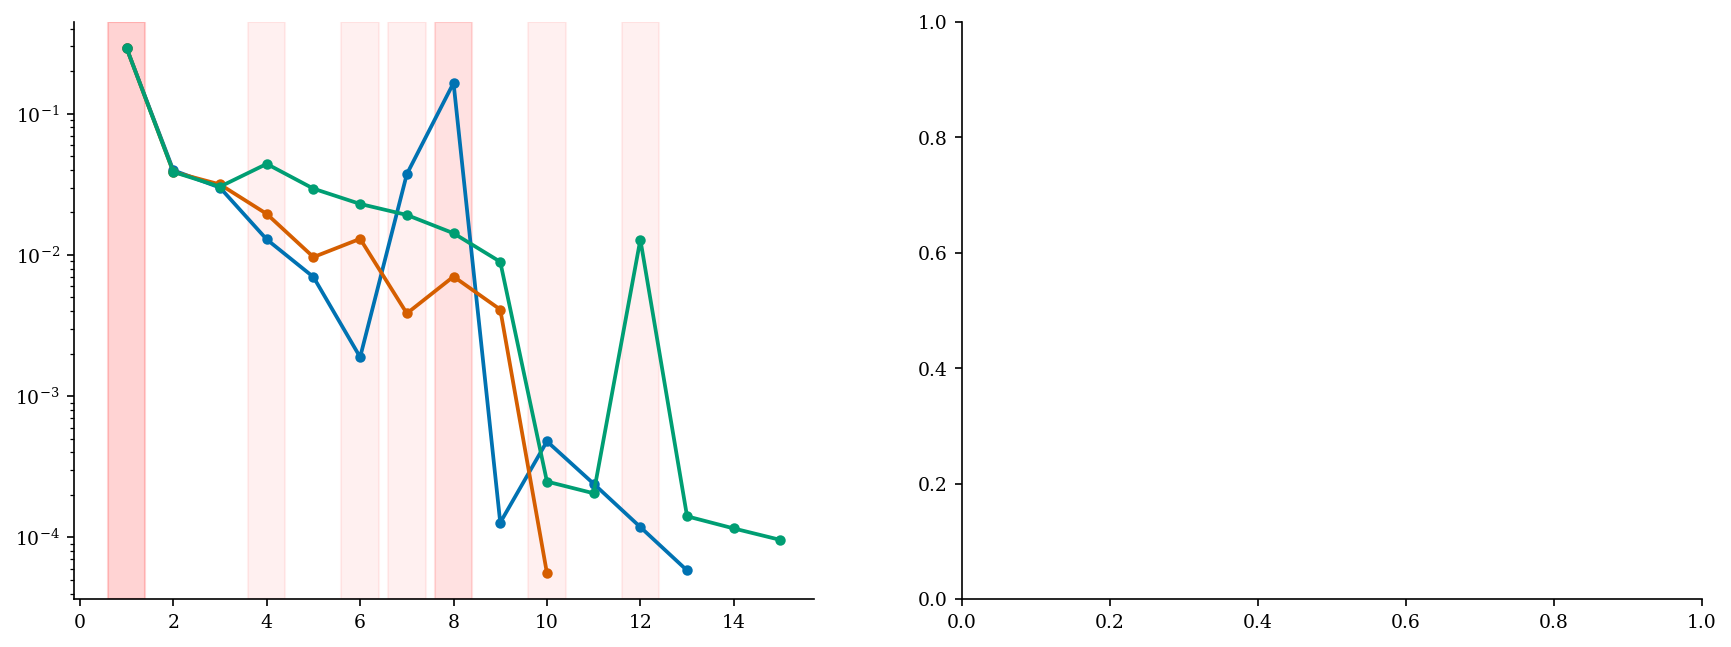

In [6]:
fig_convergence_residuals_sigma_scale()
fig_convergence_residuals_by_dataset()